In [1]:
#Load libraries and common functions
#Basics-------------------------------------------------------------------------
import os #Sistem operations
import sys #System file
import pathlib #File path
import glob #Glob files
#Data---------------------------------------------------------------------------
import numpy as np
#Graphics-----------------------------------------------------------------------
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
#Data split
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Rescaling, Conv2D, MaxPooling2D,
    Flatten, Dense, Dropout,
    RandomFlip, RandomRotation, RandomZoom
)
import tensorflow as tf

In [3]:
#Remove corrupt files
def remove_file(path):
  if os.path.exists(path):
    try:
      os.remove(path)
    except PermissionError:
      print(f'Permission Denied:{path}')
    except OSError:
      print(f'OS Error:{path}')

In [4]:
#Load data
URL = 'https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip'
CACHE_DIR = '/content'
FILE_REF = 'cats_dogs'
file_name = f'{FILE_REF}.zip'
path_to_zip = tf.keras.utils.get_file(
    file_name, origin=URL,
    extract=True, cache_dir=CACHE_DIR
    )

824887076/824887076 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [9]:
# Define parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32 #Lotes de imagenes
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE #Optimización de memoria

def load_and_decode_image_with_logging(file_path):
    """
    Attempts to read and decode an image file. If an error occurs,
    it logs the filename and returns a skip signal.
    """
    # Convert the file path Tensor to a Python string for logging
    # Use tf.py_function arguments to pass the path as a Tensor, and then decode it here
    file_path_str = file_path.numpy().decode('utf-8')

    try:
        # Read the file content
        img = tf.io.read_file(file_path)
        # Attempt to decode the image, forcing 3 channels
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])

        # Assign a dummy label (0.0) for the purpose of checking
        label = tf.constant(0.0, dtype=tf.float32)

        # Ensure the output types match the tf.py_function definition
        return img, label

    except Exception as e:
        # 🚨 This is the block that catches the error and provides the path 🚨
        if "Number of channels" in str(e) or "Input is empty" in str(e):
            print(f"\n❌ CRASHING FILE DETECTED: {file_path_str}")
            print(f"   Error: {e}")
        else:
             # Log any other unexpected error
             print(f"\n⚠️ UNCAUGHT ERROR in {file_path_str}: {e}")

        # Return tensors that can be easily filtered out
        dummy_image = tf.zeros(shape=(IMG_HEIGHT, IMG_WIDTH, 3), dtype=tf.float32)
        return dummy_image, tf.constant(-1.0, dtype=tf.float32)
def get_full_dataset(data_dir_path):
    # Get all file paths recursively
    list_ds = tf.data.Dataset.list_files(str(data_dir_path / '**/*.*'), shuffle=False, seed=SEED)

    # Apply the error-catching map function using tf.py_function
    ds = list_ds.map(lambda x: tf.py_function(
        load_and_decode_image_with_logging,
        [x],
        [tf.float32, tf.float32]), # Output types: image (float32), label (float32)
        num_parallel_calls=AUTOTUNE
    )

    # Filter out the files that caused the corruption error (label is -1.0)
    ds = ds.filter(lambda img, label: tf.equal(label, -1.0) == False)

    # Prepare for iteration
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

In [10]:
#Step 2: Preprocessing
data_dir = '/content/datasets/cats_dogs_extracted/PetImages'
data_dir_path = pathlib.Path(data_dir)

if not os.path.isdir(data_dir):
  print(f'Error directory not found: {data_dir}')
  sys.exit(1)

check_ds = get_full_dataset(data_dir_path)

In [12]:
try:
  for i,(images,labels) in enumerate(check_ds):
    print(f'BATCH {i+1}', end='\r')
    pass
except Exception as e:
  print(f'Error: {e}')
  sys.exit(1)


BATCH 14
⚠️ UNCAUGHT ERROR in /content/datasets/cats_dogs_extracted/PetImages/Cat/10404.jpg: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
BATCH 194
⚠️ UNCAUGHT ERROR in /content/datasets/cats_dogs_extracted/PetImages/Cat/4351.jpg: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input size should match (header_size + row_size * abs_height) but they differ by 2 [Op:DecodeImage] name: 

❌ CRASHING FILE DETECTED: /content/datasets/cats_dogs_extracted/PetImages/Cat/666.jpg
   Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input is empty. [Op:DecodeImage] name: 
BATCH 390
⚠️ UNCAUGHT ERROR in /content/datasets/cats_dogs_extracted/PetImages/Cat/Thumbs.db: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image fi

In [13]:
remove_file('/content/datasets/cats_dogs_extracted/PetImages/Cat/10404.jpg')
remove_file('/content/datasets/cats_dogs_extracted/PetImages/Cat/4351.jpg')
remove_file('/content/datasets/cats_dogs_extracted/PetImages/Cat/666.jpg')
remove_file('/content/datasets/cats_dogs_extracted/PetImages/Cat/Thumbs.db')
remove_file('/content/datasets/cats_dogs_extracted/PetImages/Dog/11233.jpg')
remove_file('/content/datasets/cats_dogs_extracted/PetImages/Dog/11702.jpg')
remove_file('/content/datasets/cats_dogs_extracted/PetImages/Dog/11912.jpg')
remove_file('/content/datasets/cats_dogs_extracted/PetImages/Dog/2317.jpg')
remove_file('/content/datasets/cats_dogs_extracted/PetImages/Dog/2316.jpg')
remove_file('/content/datasets/cats_dogs_extracted/PetImages/Dog/2494.jpg')
remove_file('/content/datasets/cats_dogs_extracted/PetImages/Dog/9500.jpg')
remove_file('/content/datasets/cats_dogs_extracted/PetImages/Dog/Thumbs.db')

In [14]:
image_extensions = ('**/*.jpg', '**/*.jpeg')
all_file_paths = []
for ext in image_extensions:
  all_file_paths.extend(list(data_dir_path.glob(ext)))

if not all_file_paths:
  print(f'Found 0 images: {data_dir_path}')
  sys.exit(1)

In [17]:
all_file_paths = [str(path) for path in sorted(all_file_paths)]
all_labels = [1 if '/dog/' in path.lower() or '\\dog\\' in path.lower() else
              0 if '/cat/' in path.lower() or '\\cat\\' in path.lower() else -1
              for path in all_file_paths]
clean_paths = [all_file_paths[i] for i, label in enumerate(all_labels) if label != -1]
clean_labels = [label for label in all_labels if label != -1]

In [19]:
display(len(clean_labels))
display(len(clean_paths))

24990

24990

In [20]:
train_paths, test_paths, train_labels, test_labels = train_test_split(clean_paths,
                                                                      clean_labels,
                                                                      test_size=0.2,
                                                                      random_state=SEED,
                                                                      stratify=clean_labels
                                                                      )
print(f'Train size: {len(train_paths)}, train size: {len(test_paths)}')


Train size: 19992, train size: 4998


In [21]:
def decode_img(img_path, label):
  img = tf.io.read_file(img_path)
  img = tf.image.decode_image(img, channels=3, expand_animations=False)
  img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
  img = tf.cast(img, tf.float32)
  label = tf.cast(label, tf.float32)
  return img, label

In [22]:
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

In [23]:
train_ds = (
    train_ds
    .shuffle(len(train_paths))
    .map(decode_img, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
)

test_ds = (
    test_ds
    .shuffle(len(test_paths))
    .map(decode_img, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
)

In [24]:
class_nams = ['cat', 'dog']
normalization_layer = Rescaling(1.0/255)
data_augmentation = Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.1),
    RandomZoom(0.2)
])

In [25]:
def configure_for_performance(ds, augment = False):
  ds = ds.map(lambda x, y: (normalization_layer(x),y), num_parallel_calls=AUTOTUNE)

  if augment:
    ds = ds.map(
        lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE
        )
  ds = ds.cache().prefetch(buffer_size=AUTOTUNE)
  return ds

In [26]:
train_ds_ready = configure_for_performance(train_ds, augment=True)
test_ds_ready = configure_for_performance(test_ds, augment=False)

In [40]:
model = Sequential([
    Conv2D(32, 3, activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(),
    Conv2D(64, 3, activation='relu'),
    MaxPooling2D(),
    Conv2D(128, 3, activation='relu'),
    MaxPooling2D(),
    Conv2D(256, 3, activation='relu'),
    MaxPooling2D(),
    Dropout(0.3),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568,321 (5.98 MB)

 Trainable params: 1,568,321 (5.98 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(
              optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
              metrics=['accuracy']
              )
history = model.fit(
    train_ds_ready, validation_data=test_ds,
    epochs=15
    )

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.5188 - loss: 0.6920 - val_accuracy: 0.5904 - val_loss: 34.2845
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.6141 - loss: 0.6545 - val_accuracy: 0.6242 - val_loss: 42.8459
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.6799 - loss: 0.5970 - val_accuracy: 0.6082 - val_loss: 47.0975
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.7246 - loss: 0.5389 - val_accuracy: 0.6577 - val_loss: 41.7641
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.7538 - loss: 0.4979 - val_accuracy: 0.6361 - val_loss: 51.3885
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.7754 - loss: 0.4705 - val_accuracy: 0.6357 - val_loss: 53.4882
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.7933 - loss: 0.4416 - val_accuracy: 0.6447 - val_loss: 48.5097
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.8104 - loss: 0.

In [42]:
loss = history.history['loss']
val_loss = history.history['val_loss']
mse = history.history['accuracy']
val_mse = history.history['val_accuracy']

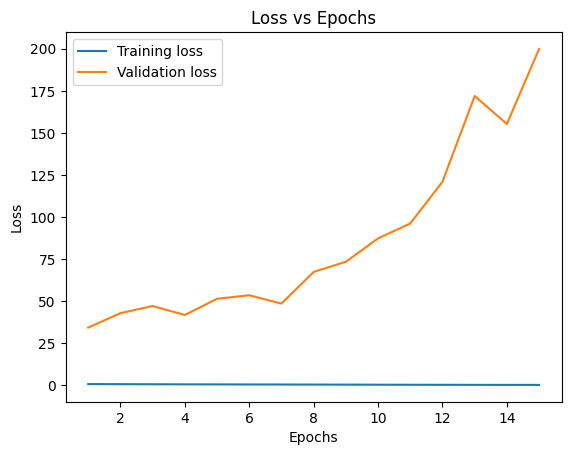

In [43]:
epochs = range(1, len(loss)+1)
plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()